In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1(a)


In [4]:
# Data
part1a = pd.read_csv('data/ml-latest-small/movies.csv')

# Year column
part1a['year'] = part1a['title'].str.extract(r'\((\d{4})\)')
part1a['year'] = pd.to_numeric(part1a['year'], errors='coerce')

# 5 year blocks
part1a['year_block'] = (part1a['year'] // 10 * 10).astype('Int64')
part1a['year_block_label'] = part1a['year_block'].apply(lambda x: f"{int(x)}-{int(x+9)}" if pd.notna(x) else None)

# Split genres and expand
part1a = part1a.assign(genre=part1a['genres'].str.split('|')).explode('genre')
part1a = part1a.dropna(subset=['year_block', 'genre'])

# Group by year block and genre
part1a_groupby = part1a.groupby(['year_block_label', 'genre']).size().reset_index(name='count')
part1a_pivot = part1a_groupby.pivot(index='genre', columns='year_block_label', values='count').fillna(0)

# Sort columns chronologically
part1a_pivot = part1a_pivot.reindex(sorted(part1a_pivot.columns, key=lambda x: int(x.split('-')[0])), axis=1)

part1a_pivot.head(10)

year_block_label,1900-1909,1910-1919,1920-1929,1930-1939,1940-1949,1950-1959,1960-1969,1970-1979,1980-1989,1990-1999,2000-2009,2010-2019
genre,,,,,,,,,,,,
(no genres listed),0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,5.0,0.0,16.0
Action,1.0,1.0,3.0,8.0,8.0,15.0,56.0,103.0,227.0,392.0,549.0,464.0
Adventure,1.0,1.0,5.0,13.0,13.0,30.0,65.0,71.0,170.0,239.0,363.0,292.0
Animation,1.0,0.0,1.0,5.0,8.0,7.0,24.0,26.0,63.0,100.0,204.0,172.0
Children,0.0,0.0,1.0,10.0,12.0,13.0,40.0,38.0,69.0,183.0,190.0,108.0
Comedy,1.0,3.0,15.0,53.0,55.0,67.0,132.0,155.0,492.0,890.0,1135.0,758.0
Crime,1.0,0.0,2.0,15.0,29.0,29.0,43.0,70.0,124.0,264.0,404.0,218.0
Documentary,0.0,0.0,1.0,2.0,1.0,1.0,8.0,11.0,26.0,73.0,198.0,119.0
Drama,0.0,3.0,16.0,74.0,118.0,146.0,192.0,225.0,439.0,1038.0,1365.0,743.0


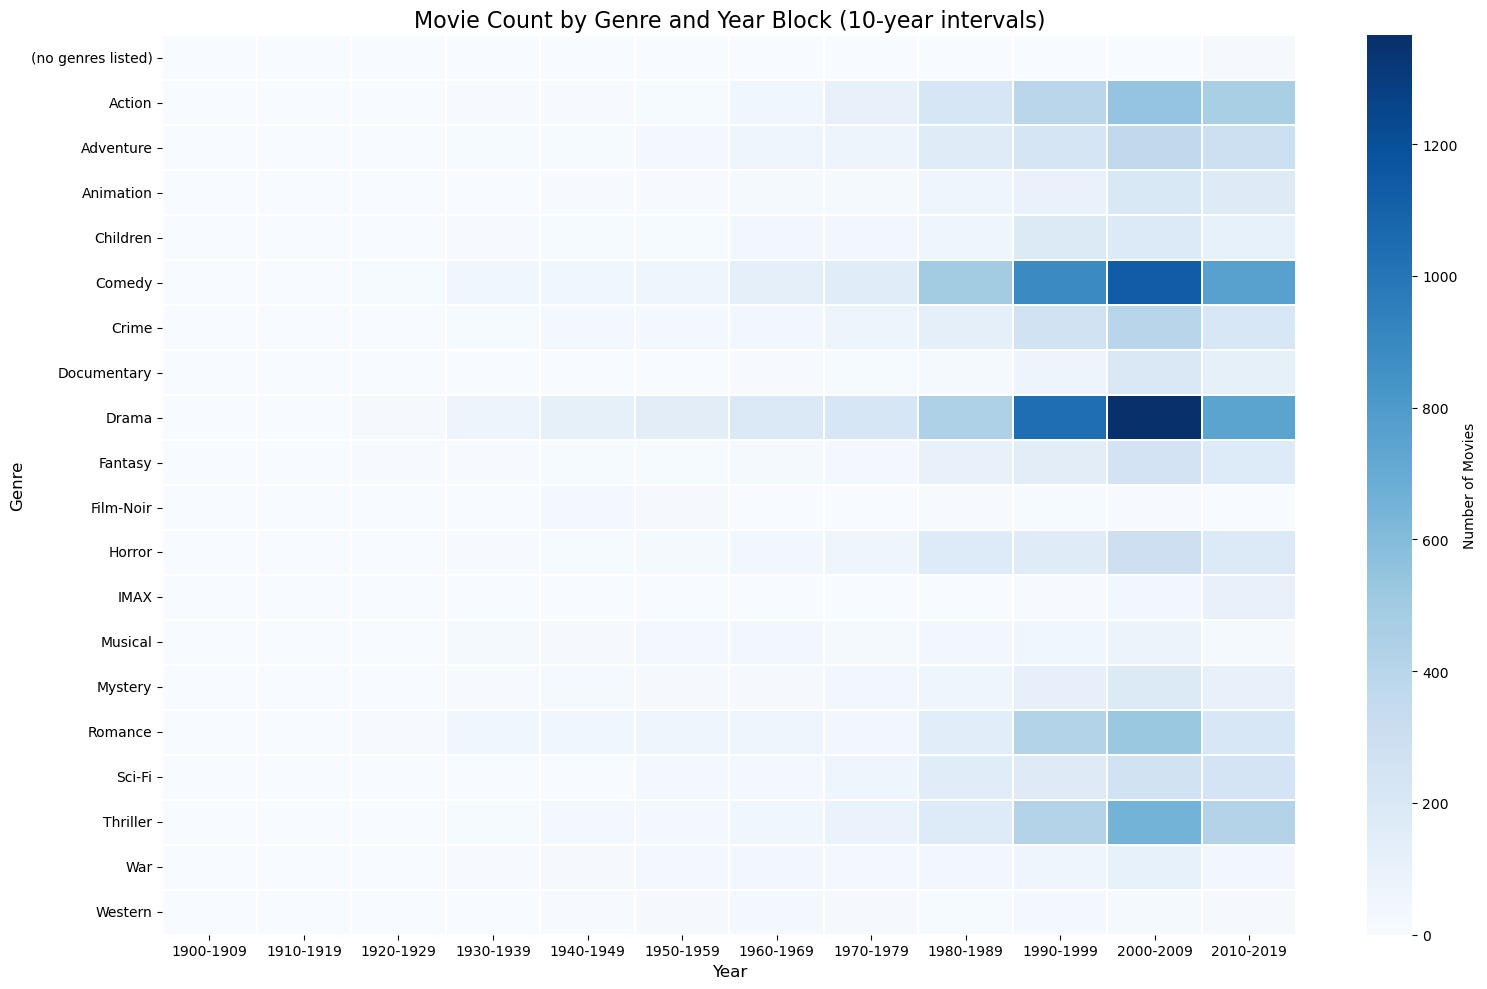

In [5]:
plt.figure(figsize=(16,10))
sns.heatmap(part1a_pivot, cmap='Blues', cbar_kws={'label': 'Number of Movies'}, linewidths=0.1)
plt.title('Movie Count by Genre and Year Block (10-year intervals)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

## Part 1(b)


In [6]:
# Reviews
reviews = pd.read_csv('data/ml-latest-small/ratings.csv')[['movieId', 'rating']]

#Join
part1b = part1a.merge(reviews, on='movieId', how='left')

part1b.head()

,movieId,title,genres,year,year_block,year_block_label,genre,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,4.0
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,4.0
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,4.5
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,2.5
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,1990,1990-1999,Adventure,4.5


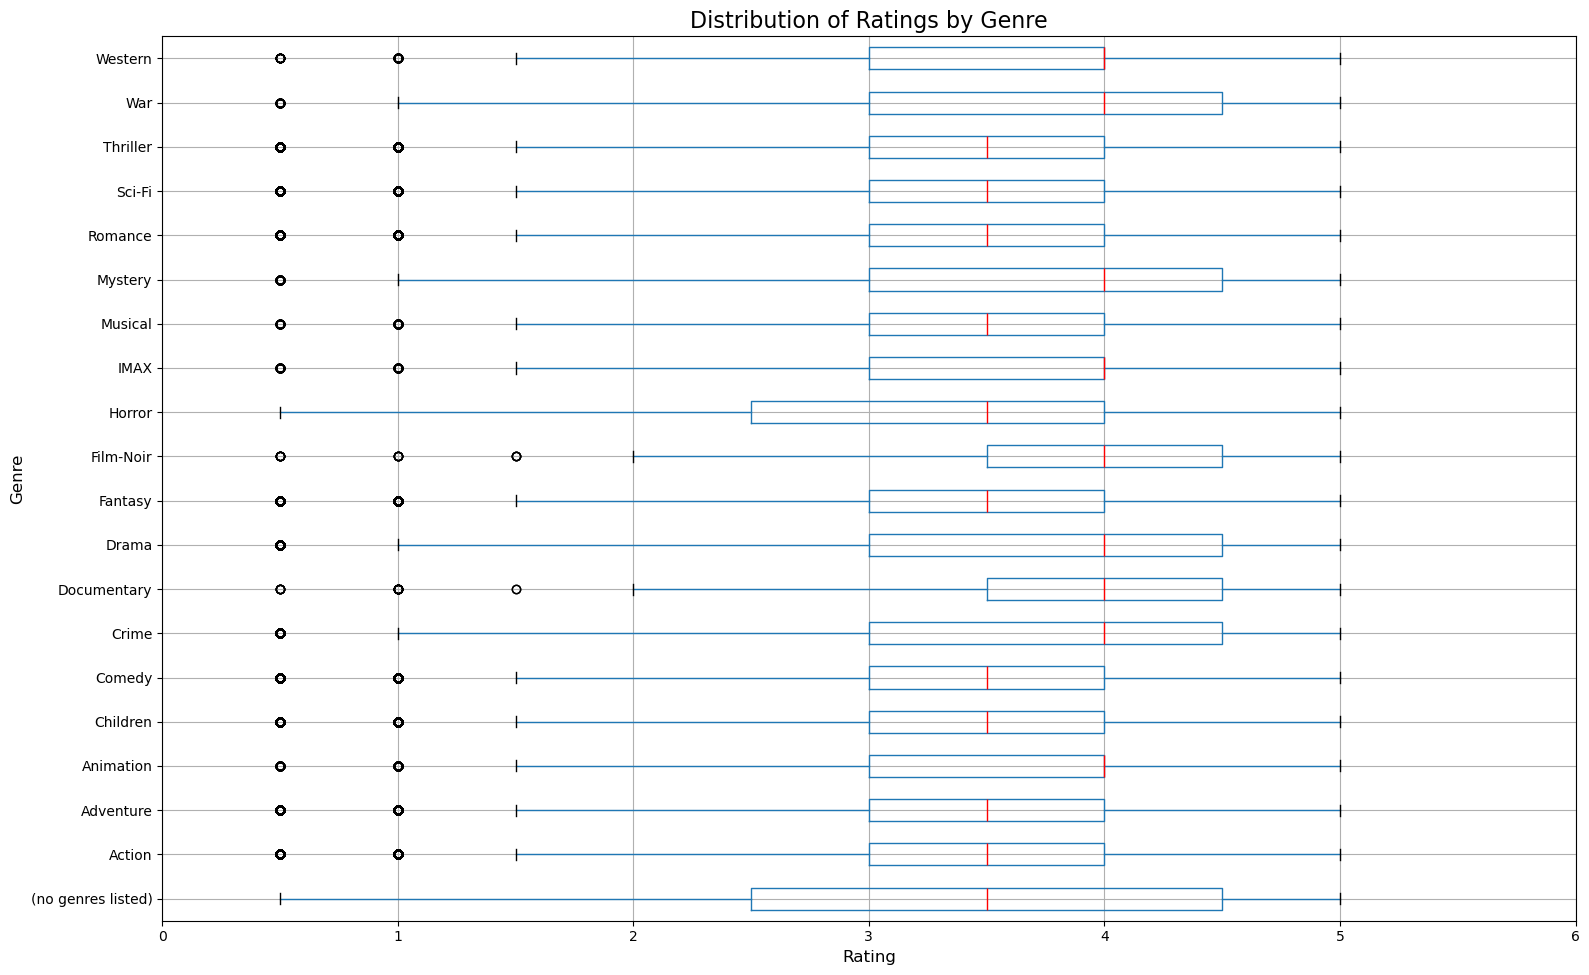

In [21]:
part1b.boxplot(column='rating', by='genre', figsize=(16,10), vert=False, medianprops=dict[str, str](color='red'))
plt.ylabel('Genre', fontsize=12)
plt.xlabel('Rating', fontsize=12)
plt.title('Distribution of Ratings by Genre', fontsize=16)
plt.xlim(0, 6)
plt.suptitle('')
plt.tight_layout()
plt.show()

## Part 2


## Part 3
